## Neural Network Approach for Seasonal Items Forecasting of a Retail Store
## Prophet method

## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
%matplotlib inline
import seaborn as sns
from statsmodels.graphics import tsaplots
import statsmodels.api as sm
from pylab import rcParams
import itertools
import warnings
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import sys

## Load Dataset

In [3]:
data= pd.read_excel('MRP_data.xls')

## Edit columns names

In [4]:
# Lower case column names
data.columns = map(str.lower, data.columns)

#Replace spaces with '_'
data.columns = data.columns.str.replace(" ", "_")
data.columns = data.columns.str.replace("-", "_")
data.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

## Separate dataframe of each category

In [5]:
furniture=data.loc[data['category'] == 'Furniture']

technology=data.loc[data['category'] == 'Technology']
office=data.loc[data['category'] == 'Office Supplies']

## Aggregating sales data by date

In [6]:
furniture= furniture.groupby('order_date')['sales'].sum().reset_index()

technology= technology.groupby('order_date')['sales'].sum().reset_index()
office= office.groupby('order_date')['sales'].sum().reset_index()

In [7]:
#Set index
furniture = furniture.set_index('order_date')

technology = technology.set_index('order_date')
office = office.set_index('order_date')

In [8]:
#Resampling the data on monthly frequency
# Using averages daily sales value - set start of the month as index
df = furniture['sales'].resample('MS').mean()

#avg_technology_sales = technology_sales['sales'].resample('MS').mean()
#avg_office_sales = office_sales['sales'].resample('MS').mean()

### Train and test split

In [9]:
X = df
train_size = int(len(X) * 0.75)
trainset, testset= X[0:train_size], X[train_size:]

## Prophet First model

In [10]:
#df_furniture = pd.DataFrame({'order_date':df.index, 'sales':df.values})
df_furniture_train = pd.DataFrame({'order_date':trainset.index, 'sales':trainset.values})
df_furniture_test = pd.DataFrame({'order_date':testset.index, 'sales':testset.values})

In [13]:
warnings.filterwarnings("ignore")
from prophet import Prophet
#df_furniture = df_furniture.rename(columns={'order_date': 'ds', 'sales': 'y'})
df_furniture_train = df_furniture_train.rename(columns={'order_date': 'ds', 'sales': 'y'})
df_furniture_test = df_furniture_test.rename(columns={'order_date': 'ds', 'sales': 'y'})

In [14]:
# set the uncertainty interval to 95% (Prophet default is 80%)
furniture_model = Prophet(interval_width=0.95)
#furniture_model.fit(df_furniture)
furniture_model.fit(df_furniture_train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6ifyi0xe/bmmwfloq.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6ifyi0xe/n6tj1z6r.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=57926', 'data', 'file=/tmp/tmp6ifyi0xe/bmmwfloq.json', 'init=/tmp/tmp6ifyi0xe/n6tj1z6r.json', 'output', 'file=/tmp/tmp6ifyi0xe/prophet_modeluh601wvq/prophet_model-20240527105542.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
10:55:42 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
10:55:43 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [15]:
furniture_forecast = furniture_model.make_future_dataframe(periods=12, freq='MS')
furniture_forecast = furniture_model.predict(furniture_forecast)

<Figure size 1800x600 with 0 Axes>

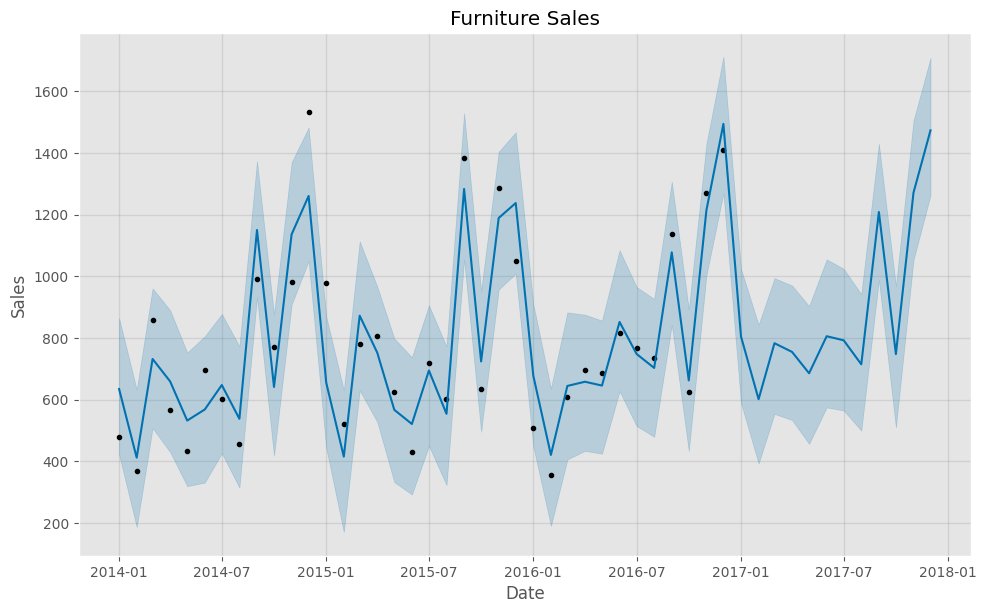

In [16]:
plt.figure(figsize=(18, 6))
furniture_model.plot(furniture_forecast, xlabel = 'Date', ylabel = 'Sales')
plt.title('Furniture Sales')
plt.show()

In [17]:
furniture_forecast.drop(columns=['multiplicative_terms', 'multiplicative_terms_lower','multiplicative_terms_upper'])

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,yhat
0,2014-01-01,681.587747,421.310852,864.042032,681.587747,681.587747,-47.448368,-47.448368,-47.448368,-47.448368,-47.448368,-47.448368,634.139379
1,2014-02-01,685.635861,186.621637,632.042546,685.635861,685.635861,-274.074947,-274.074947,-274.074947,-274.074947,-274.074947,-274.074947,411.560915
2,2014-03-01,689.292223,507.300691,960.818510,689.292223,689.292223,42.431306,42.431306,42.431306,42.431306,42.431306,42.431306,731.723529
3,2014-04-01,693.340337,429.592591,889.824353,693.340337,693.340337,-34.565318,-34.565318,-34.565318,-34.565318,-34.565318,-34.565318,658.775020
4,2014-05-01,697.257867,319.213880,752.568998,697.257867,697.257867,-165.309770,-165.309770,-165.309770,-165.309770,-165.309770,-165.309770,531.948097
5,2014-06-01,701.305982,330.755189,805.326484,701.305982,701.305982,-133.386435,-133.386435,-133.386435,-133.386435,-133.386435,-133.386435,567.919547
6,2014-07-01,705.223512,426.089768,877.615560,705.223512,705.223512,-58.042820,-58.042820,-58.042820,-58.042820,-58.042820,-58.042820,647.180692
7,2014-08-01,709.271626,314.394216,772.734997,709.271626,709.271626,-171.625954,-171.625954,-171.625954,-171.625954,-171.625954,-171.625954,537.645672
8,2014-09-01,713.319740,931.060984,1373.319497,713.319740,713.319740,436.757415,436.757415,436.757415,436.757415,436.757415,436.757415,1150.077155
9,2014-10-01,717.237270,418.311700,876.161590,717.237270,717.237270,-76.341805,-76.341805,-76.341805,-76.341805,-76.341805,-76.341805,640.895465


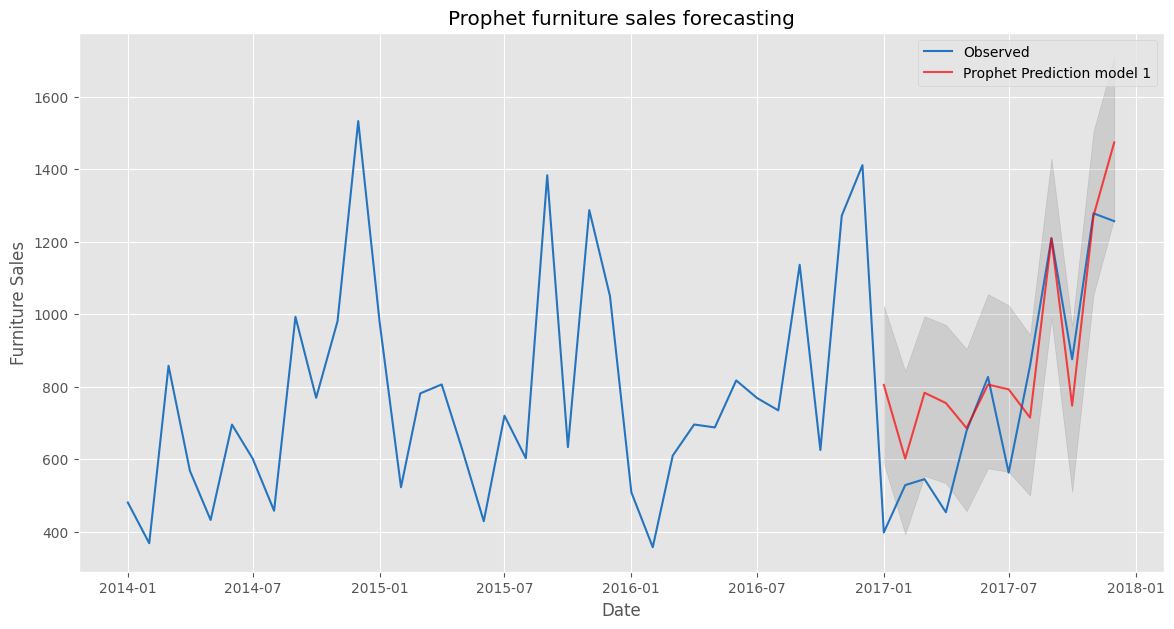

In [18]:
rcParams['figure.figsize'] = 14, 7
plt.plot(df.index, df.values,label='Observed',color='#2574BF')
plt.plot(df[36:48].index,furniture_forecast[36:48]['yhat'].values,label='Prophet Prediction model 1', alpha= 0.7, color='red')
plt.fill_between(df[36:48].index,
                #lower sales
                furniture_forecast[36:48]['yhat_lower'].values,
                #upper sales
                furniture_forecast[36:48]['yhat_upper'].values, color='k', alpha=0.1)
plt.title('Prophet furniture sales forecasting')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.show()

In [19]:
def performance(y_true, y_pred):
    #y_true, y_pred = np.array(y_true), np.array(y_pred)
    mse = ((y_pred - y_true) ** 2).mean()
    mape= np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return( print(' The MSE of forecasts is {}'.format(round(mse, 2))+
                  '\n The RMSE of forecasts is {}'.format(round(np.sqrt(mse), 2))+
                  '\n The MAPE of forecasts is {}'.format(round(mape, 2))))

In [20]:
performance(df[36:48].values, furniture_forecast[36:48]['yhat'])

 The MSE of forecasts is 37992.43
 The RMSE of forecasts is 194.92
 The MAPE of forecasts is 26.67


### Prophet Second model - applying holiday

In [21]:
#add holidays
new_year_holidays = pd.DataFrame({'holiday': "New Year's Day", 'ds' : pd.to_datetime(['2014-01-01', '2015-01-01','2016-01-01'])})
# more accurate without holidays!
furniture_model2 = Prophet(yearly_seasonality=True, holidays=new_year_holidays)
#furniture_model2.fit(df_furniture)
furniture_model2.fit(df_furniture_train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6ifyi0xe/4m3by38g.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6ifyi0xe/ln_1hivn.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=324', 'data', 'file=/tmp/tmp6ifyi0xe/4m3by38g.json', 'init=/tmp/tmp6ifyi0xe/ln_1hivn.json', 'output', 'file=/tmp/tmp6ifyi0xe/prophet_model2w23ppos/prophet_model-20240527105659.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
10:56:59 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
10:56:59 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [22]:
furniture_forecast2 = furniture_model2.make_future_dataframe(periods=36, freq='MS')
furniture_forecast2 = furniture_model2.predict(furniture_forecast2)

<Figure size 1800x600 with 0 Axes>

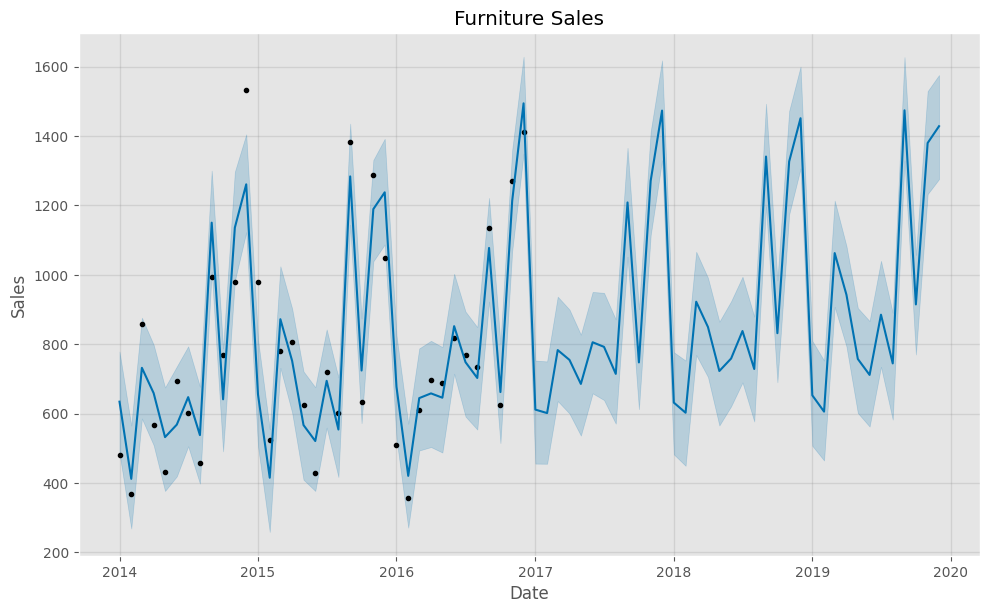

In [23]:
plt.figure(figsize=(18, 6))
furniture_model2.plot(furniture_forecast2, xlabel = 'Date', ylabel = 'Sales')
plt.title('Furniture Sales')
plt.show()

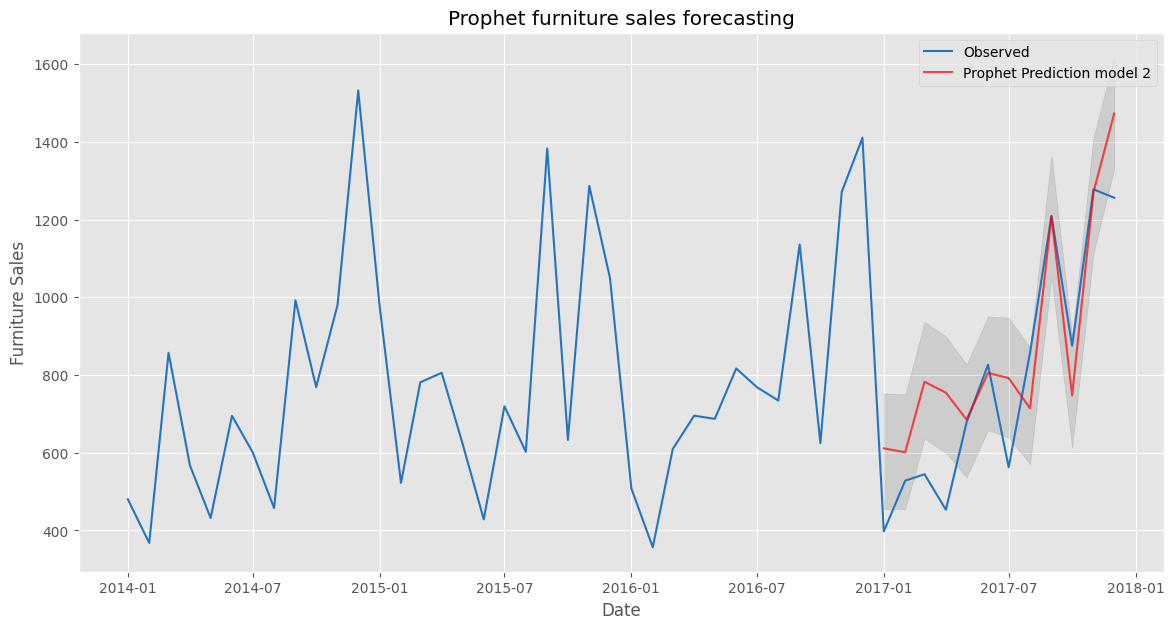

In [24]:
rcParams['figure.figsize'] = 14, 7
plt.plot(df.index, df.values,label='Observed',color='#2574BF')
plt.plot(df[36:48].index,furniture_forecast2[36:48]['yhat'].values,label='Prophet Prediction model 2', alpha= 0.7, color='red')
plt.fill_between(df[36:48].index,
                #lower sales
                furniture_forecast2[36:48]['yhat_lower'].values,
                #upper sales
                furniture_forecast2[36:48]['yhat_upper'].values, color='k', alpha=0.1)
plt.title('Prophet furniture sales forecasting')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.show()

In [25]:
performance(df[36:48].values, furniture_forecast2[36:48]['yhat'])

 The MSE of forecasts is 27986.69
 The RMSE of forecasts is 167.29
 The MAPE of forecasts is 22.62
